# XGBoost (Optuna-tuned, xgb_matched) — WEEKLY refit, regularised, + regime-aware ensemble — vs OLS/HAR

Two Optuna-tuned XGBoost runs on `xgb_matched` `[x_d, x_w, x_m, log_GVZ, macro]`, differing only in the
4-fold CV aggregation in tuning — **`xgb_optuna_recency`** (folds 0.14/0.20/0.29/0.41) vs
**`xgb_optuna_equal`** (0.25 each) — compared (MCS) against the **OLS/HAR** specs, plus a **regime-aware
ensemble** of XGBoost and OLS.

**Regime-aware ensemble (new).** Blends the **forecasts** of `xgb_optuna_recency` (XGBoost) and `har_run18`
(matched-feature OLS) by volatility regime:
- **High-vol regime** — current day's RV above its **expanding 95th percentile** → **75% XGBoost / 25% OLS**.
- **Low-vol regime** — otherwise → **75% OLS / 25% XGBoost**.

No look-ahead: the regime uses the **current** day's realized vol (RV at day _t_, known when forecasting
_t+1_) and an **expanding** quantile threshold built only from data up to _t_.

**Model (both XGB runs):** `reg:squarederror` on level RV (QLIKE only as early-stop + selection metric);
within-fold training equal-weight; early stopping sets tree count; nested walk-forward CV (inner 4-fold WFCV
inside each 6y window; annual re-tune ~9 studies × 30 TPE trials, seed=42; outer rolling OOS, leak-free);
**weekly refit (5 days)**; wider L1/L2 (`reg_lambda, reg_alpha ∈ [1e-3,50]`); threads capped at 2.

In [1]:
# ===========================================================================
# Cell 1 — Imports & data
# ===========================================================================
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import xgboost as xgb
import optuna
from arch.bootstrap import MCS
optuna.logging.set_verbosity(optuna.logging.WARNING)

data = pd.read_parquet("merged_RV_GVZ_with_macro_event.parquet")
rv = data["RV_gold"].astype(float)

TRADING_DAYS = 252
WINDOW_YEARS = np.arange(1.0, 7.001, 0.25)
WINDOWS = [int(round(yr * TRADING_DAYS)) for yr in WINDOW_YEARS]
WINDOW = 6 * TRADING_DAYS
DELTA = 0.999                             # HAR/OLS recency decay
TRAIN_DELTA = 1.0                         # XGBoost within-fold/refit per-obs weight = EQUAL
REFIT_EVERY = 5                           # WEEKLY refit
TUNE_EVERY = TRADING_DAYS                 # annual re-tune
N_TRIALS = 30
NTHREAD = 2
EPS = 1e-6
REGIME_Q = 0.95                           # high-vol = current RV above expanding 95th pct
FOLD_WEIGHTS_RECENCY = [0.14, 0.20, 0.29, 0.41]
FOLD_WEIGHTS_EQUAL   = [0.25, 0.25, 0.25, 0.25]
print(f"WINDOW={WINDOW}; REFIT_EVERY={REFIT_EVERY} (weekly); REGIME_Q={REGIME_Q}; "
      f"N_TRIALS={N_TRIALS}; NTHREAD={NTHREAD}; xgboost {xgb.__version__}; optuna {optuna.__version__}")

WINDOW=1512; REFIT_EVERY=5 (weekly); REGIME_Q=0.95; N_TRIALS=30; NTHREAD=2; xgboost 3.2.0; optuna 4.9.0


/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# ===========================================================================
# Cell 2 — Build the matched design table (y_log kept for the OLS leg)
# ===========================================================================
x = np.log(rv)
def build_log_design(extra_cols):
    df = pd.DataFrame(index=rv.index)
    df["x_d"] = x; df["x_w"] = x.rolling(5).mean(); df["x_m"] = x.rolling(22).mean()
    for name, s in extra_cols.items():
        df[name] = s.reindex(rv.index)
    df["y_log"]   = x.shift(-1)          # log(RV_{t+1}) — OLS target
    df["y_level"] = rv.shift(-1)         # RV_{t+1} — XGBoost target / QLIKE actual
    return df.dropna()
macro = data["macro_event"].shift(-1).astype(float)
d_matched = build_log_design({"log_GVZ": np.log(data["GVZ_close"]), "macro": macro})
feats_matched = ["x_d", "x_w", "x_m", "log_GVZ", "macro"]
print("matched design:", len(d_matched), "rows; feats:", feats_matched)

matched design: 3993 rows; feats: ['x_d', 'x_w', 'x_m', 'log_GVZ', 'macro']


In [3]:
# ===========================================================================
# Cell 2b — Collinearity diagnostic (correlation + VIF)
# ===========================================================================
Xf = d_matched[feats_matched]
corr = Xf.corr()
print("Feature correlation matrix:"); print(corr.round(3).to_string())
vif = pd.Series(np.diag(np.linalg.inv(corr.to_numpy())), index=feats_matched, name="VIF")
print("\nVariance Inflation Factors (>10 = serious collinearity):"); print(vif.round(2).to_string())

Feature correlation matrix:
           x_d    x_w    x_m  log_GVZ  macro
x_d      1.000  0.830  0.701    0.778 -0.005
x_w      0.830  1.000  0.861    0.883 -0.004
x_m      0.701  0.861  1.000    0.891 -0.014
log_GVZ  0.778  0.883  0.891    1.000 -0.011
macro   -0.005 -0.004 -0.014   -0.011  1.000

Variance Inflation Factors (>10 = serious collinearity):
x_d        3.42
x_w        6.97
x_m        5.68
log_GVZ    6.87
macro      1.00


In [4]:
# ===========================================================================
# Cell 3 — Helpers: weights, QLIKE, QLIKE metric, ES fit, OLS forecast
# ===========================================================================
START_DATE = d_matched.index[max(WINDOWS)]
ESR, CAP = 40, 1000
WF_EDGES = [0.20, 0.40, 0.60, 0.80, 1.00]

def _recency_weights(n, delta):
    if delta >= 1.0:
        return np.ones(n)
    ages = np.arange(n)[::-1]; w = delta ** ages
    return w * (n / w.sum())

def _qlike(actual, forecast, eps=EPS):
    f = np.maximum(forecast, eps); r = actual / f
    return r - np.log(r) - 1.0, int((forecast <= eps).sum())

def _qlike_feval(preds, dmat):
    y = dmat.get_label(); f = np.maximum(preds, EPS); r = y / f
    return "qlike", float(np.mean(r - np.log(r) - 1.0))

def _es_fit(Xtr, ytr, wtr, Xvl, yvl, params):
    dtr = xgb.DMatrix(Xtr, label=ytr, weight=wtr)
    dvl = xgb.DMatrix(Xvl, label=yvl)
    return xgb.train(params, dtr, num_boost_round=CAP, custom_metric=_qlike_feval,
                     evals=[(dvl, "val")], early_stopping_rounds=ESR, maximize=False,
                     verbose_eval=False)

def _to_xgb(bp):
    return dict(objective="reg:squarederror", max_depth=bp["max_depth"], eta=bp["learning_rate"],
                min_child_weight=bp["min_child_weight"], subsample=bp["subsample"],
                colsample_bytree=bp["colsample_bytree"], reg_lambda=bp["reg_lambda"],
                reg_alpha=bp["reg_alpha"], gamma=bp["gamma"], tree_method="hist", nthread=NTHREAD)

def rolling_log_ols_forecast(design, feat_cols, window=WINDOW, delta=DELTA, start_date=None):
    """Weighted log-OLS HAR (daily refit, Duan smearing) -> LEVEL forecast Series. = har_run18 when
    feat_cols are the matched columns. Mirrors HAR_simpleOLS_3d_with_macro."""
    if start_date is None:
        start_date = START_DATE
    X = np.column_stack([np.ones(len(design)), design[feat_cols].to_numpy()])
    yl = design["y_log"].to_numpy(); idx = design.index; N, p = X.shape
    t_oos = np.arange(window, N)[idx[window:] >= start_date]; starts = t_oos - window
    Xwins = np.lib.stride_tricks.sliding_window_view(X, window, axis=0)[starts].transpose(0, 2, 1)
    ywins = np.lib.stride_tricks.sliding_window_view(yl, window)[starts]
    w = _recency_weights(window, delta); sw = np.sqrt(w)
    Xs = Xwins * sw[None, :, None]; ys = ywins * sw[None, :]
    beta = np.linalg.solve(np.einsum("nwi,nwj->nij", Xs, Xs), np.einsum("nwi,nw->ni", Xs, ys))
    fitted = np.einsum("nwp,np->nw", Xwins, beta)
    smear = np.einsum("nw,w->n", np.exp(ywins - fitted), w) / w.sum()
    fc = np.exp(np.einsum("np,np->n", X[t_oos], beta)) * smear
    return pd.Series(fc, index=idx[t_oos], name="fc")

print(f"Common OOS start: {START_DATE.date()}  "
      f"({int((d_matched.index >= START_DATE).sum())} forecast days)")

Common OOS start: 2017-07-11  (2229 forecast days)


In [5]:
# ===========================================================================
# Cell 4 — Optuna study on one window (wider L1/L2)
# ===========================================================================
def tune_window(Xw, yw, fold_weights, n_trials=N_TRIALS, train_delta=TRAIN_DELTA, seed=42):
    n = len(Xw); w_full = _recency_weights(n, train_delta)
    edges = [int(round(f * n)) for f in WF_EDGES]
    folds = [(0, edges[k], edges[k + 1]) for k in range(4)]

    def objective(trial):
        params = dict(
            objective="reg:squarederror",
            max_depth=trial.suggest_int("max_depth", 2, 4),
            eta=trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
            min_child_weight=trial.suggest_int("min_child_weight", 1, 20),
            subsample=trial.suggest_float("subsample", 0.5, 1.0),
            colsample_bytree=trial.suggest_float("colsample_bytree", 0.5, 1.0),
            reg_lambda=trial.suggest_float("reg_lambda", 1e-3, 50, log=True),
            reg_alpha=trial.suggest_float("reg_alpha", 1e-3, 50, log=True),
            gamma=trial.suggest_float("gamma", 0.0, 5.0),
            tree_method="hist", nthread=NTHREAD)
        fold_q = []
        for tr0, v0, v1 in folds:
            wtr = w_full[tr0:v0] * ((v0 - tr0) / w_full[tr0:v0].sum())
            b = _es_fit(Xw[tr0:v0], yw[tr0:v0], wtr, Xw[v0:v1], yw[v0:v1], params)
            fold_q.append(b.best_score)
        return float(np.average(fold_q, weights=fold_weights))

    study = optuna.create_study(direction="minimize",
                                sampler=optuna.samplers.TPESampler(seed=seed))
    study.optimize(objective, n_trials=n_trials)
    return study.best_params, study.best_value

print("tune_window ready")

tune_window ready


In [6]:
# ===========================================================================
# Cell 5 — Annual re-tune + weekly refit; returns LOSS and FORECAST series
# ===========================================================================
def _fit_full(Xw, yw, train_delta, xgb_params):
    n = len(Xw); w_full = _recency_weights(n, train_delta); split = int(round(0.80 * n))
    wtr = w_full[:split] * (split / w_full[:split].sum())
    b0 = _es_fit(Xw[:split], yw[:split], wtr, Xw[split:], yw[split:], xgb_params)
    dall = xgb.DMatrix(Xw, label=yw, weight=w_full)
    return xgb.train(xgb_params, dall, num_boost_round=max(int(b0.best_iteration) + 1, 1),
                     verbose_eval=False)

def run_optuna_walkforward(design, feat_cols, fold_weights, label,
                           train_delta=TRAIN_DELTA, window=WINDOW, refit_every=REFIT_EVERY,
                           tune_every=TUNE_EVERY, n_trials=N_TRIALS):
    Xall = design[feat_cols].to_numpy(); lvl = design["y_level"].to_numpy(); idx = design.index
    N = len(design)
    t_oos = np.arange(window, N)[idx[window:] >= START_DATE]
    tune_pos = list(range(0, len(t_oos), tune_every))
    t0 = time.time()
    params_at, param_rows = {}, []
    for tp in tune_pos:
        r = t_oos[tp]
        bp, bv = tune_window(Xall[r - window:r], lvl[r - window:r], fold_weights,
                             n_trials=n_trials, train_delta=train_delta)
        params_at[tp] = bp
        param_rows.append({"date": idx[r], "cv_qlike": bv, **bp})
    fc = np.empty(len(t_oos)); imp = np.zeros(len(feat_cols)); n_models = 0
    for p0 in range(0, len(t_oos), refit_every):
        tp = max(t for t in tune_pos if t <= p0)
        xgb_params = _to_xgb(params_at[tp])
        r = t_oos[p0]
        bst = _fit_full(Xall[r - window:r], lvl[r - window:r], train_delta, xgb_params)
        block = t_oos[p0:p0 + refit_every]
        fc[p0:p0 + refit_every] = np.maximum(bst.predict(xgb.DMatrix(Xall[block])), EPS)
        g = bst.get_score(importance_type="gain")
        v = np.array([g.get(f"f{j}", 0.0) for j in range(len(feat_cols))])
        if v.sum() > 0:
            imp += v / v.sum(); n_models += 1
    q, clip = _qlike(lvl[t_oos], fc)
    imp = pd.Series(imp / max(n_models, 1), index=feat_cols).sort_values(ascending=False)
    params_df = pd.DataFrame(param_rows).set_index("date")
    fc_series = pd.Series(fc, index=idx[t_oos], name="fc")
    q_series = pd.Series(q, index=idx[t_oos], name="qlike")
    print(f"[{label}] mean QLIKE={q.mean():.6f}  clipped={clip}  refits={int(np.ceil(len(t_oos)/refit_every))}  "
          f"elapsed={time.time()-t0:.0f}s")
    return q_series, fc_series, imp, params_df

xgb_optuna_recency, fc_rec, imp_rec, params_rec = run_optuna_walkforward(
    d_matched, feats_matched, FOLD_WEIGHTS_RECENCY, "xgb_optuna_recency")
xgb_optuna_equal, fc_eq, imp_eq, params_eq = run_optuna_walkforward(
    d_matched, feats_matched, FOLD_WEIGHTS_EQUAL, "xgb_optuna_equal")

[xgb_optuna_recency] mean QLIKE=0.030527  clipped=0  refits=446  elapsed=83s


[xgb_optuna_equal] mean QLIKE=0.030634  clipped=0  refits=446  elapsed=67s


In [7]:
# ===========================================================================
# Cell 6 — Regime-aware ensemble (75/25 XGB-OLS by high/low vol regime)
# ===========================================================================
# OLS leg = har_run18 forecast (matched features, log-OLS + Duan smearing, daily refit, delta=0.999).
fc_ols = rolling_log_ols_forecast(d_matched, feats_matched, delta=DELTA)
oos = xgb_optuna_recency.index
y_oos = d_matched["y_level"].reindex(oos).to_numpy()

# Sanity: this OLS forecast should reproduce cached har_run18 (~0.027551).
q_ols, _ = _qlike(y_oos, fc_ols.reindex(oos).to_numpy())
print(f"OLS leg (har_run18) mean QLIKE = {q_ols.mean():.6f}  (cached har_run18 ~0.027551)")

# Regime: current-day RV vs EXPANDING 95th pct (both known at t -> no look-ahead).
cur_vol = rv.reindex(oos).to_numpy()                              # RV on day t (current)
thr95   = rv.expanding().quantile(REGIME_Q).reindex(oos).to_numpy()
regime_high = cur_vol > thr95                                     # top-5% vol days
print(f"High-vol OOS days: {int(regime_high.sum())} / {len(regime_high)} "
      f"({100*regime_high.mean():.1f}%)")

# Blend the FORECASTS: high -> 0.75 XGB + 0.25 OLS; low -> 0.25 XGB + 0.75 OLS.
fc_x = fc_rec.reindex(oos).to_numpy(); fc_o = fc_ols.reindex(oos).to_numpy()
w_xgb = np.where(regime_high, 0.75, 0.25)
fc_ens = w_xgb * fc_x + (1.0 - w_xgb) * fc_o
q_ens, clip_ens = _qlike(y_oos, fc_ens)
regime_ensemble = pd.Series(q_ens, index=oos, name="qlike")
print(f"[regime_ensemble] mean QLIKE = {regime_ensemble.mean():.6f}  clipped={clip_ens}")

OLS leg (har_run18) mean QLIKE = 0.027551  (cached har_run18 ~0.027551)
High-vol OOS days: 125 / 2229 (5.6%)
[regime_ensemble] mean QLIKE = 0.028318  clipped=0


In [8]:
# ===========================================================================
# Cell 7 — Loss matrix (all methods incl. regime ensemble) + MCS
# ===========================================================================
cached = pd.read_parquet("xgb_vs_har_losses_6y.parquet")
losses = (cached[["har_run18", "har_run19", "har_run20"]]
          .join(xgb_optuna_recency.rename("xgb_optuna_recency"), how="inner")
          .join(xgb_optuna_equal.rename("xgb_optuna_equal"), how="inner")
          .join(regime_ensemble.rename("regime_ensemble"), how="inner"))
assert losses.notna().all().all() and len(losses) == len(cached), "OOS dates not aligned"
losses.to_parquet("xgb_optuna_regime_losses_6y.parquet")
print(f"Aligned loss matrix: {losses.shape[0]} OOS days x {losses.shape[1]} models")
print("\nMean QLIKE (lower = better):")
print(losses.mean().sort_values().rename("mean_qlike").to_frame().to_string())

mcs = MCS(losses, size=0.05, reps=10000, block_size=None,
          method="R", bootstrap="stationary", seed=42)
mcs.compute()
pv = mcs.pvalues["Pvalue"]
mcs_results = (pd.DataFrame({"mean_qlike": losses.mean(), "mcs_pvalue": pv})
               .assign(in_mcs=lambda d: d["mcs_pvalue"] > 0.05)
               .sort_values("mean_qlike"))
mcs_results.to_parquet("mcs_xgb_optuna_regime_6y.parquet")
pd.set_option("display.float_format", lambda v: f"{v:.6f}")
print("\nModel Confidence Set (size=0.05, reps=10000, stationary bootstrap):")
print(mcs_results.to_string())
print(f"\nBest: {mcs_results.index[0]}  | In 5% MCS: {list(mcs_results.index[mcs_results['in_mcs']])}")
mcs_results

Aligned loss matrix: 2229 OOS days x 6 models

Mean QLIKE (lower = better):
                    mean_qlike
har_run20             0.027481
har_run19             0.027546
har_run18             0.027551
regime_ensemble       0.028318
xgb_optuna_recency    0.030527
xgb_optuna_equal      0.030634



Model Confidence Set (size=0.05, reps=10000, stationary bootstrap):
                    mean_qlike  mcs_pvalue  in_mcs
har_run20             0.027481    1.000000    True
har_run19             0.027546    0.550000    True
har_run18             0.027551    0.550000    True
regime_ensemble       0.028318    0.319400    True
xgb_optuna_recency    0.030527    0.027700   False
xgb_optuna_equal      0.030634    0.023200   False

Best: har_run20  | In 5% MCS: ['har_run20', 'har_run19', 'har_run18', 'regime_ensemble']


,mean_qlike,mcs_pvalue,in_mcs
har_run20,0.027481,1.000000,True
har_run19,0.027546,0.550000,True
har_run18,0.027551,0.550000,True
regime_ensemble,0.028318,0.319400,True
xgb_optuna_recency,0.030527,0.027700,False
xgb_optuna_equal,0.030634,0.023200,False


In [9]:
# ===========================================================================
# Cell 7b — Per-regime QLIKE breakdown (does XGBoost help in high-vol days?)
# ===========================================================================
breakdown = pd.DataFrame({
    f"high_vol (n={int(regime_high.sum())})": losses[regime_high].mean(),
    f"low_vol (n={int((~regime_high).sum())})": losses[~regime_high].mean(),
}).sort_values(f"high_vol (n={int(regime_high.sum())})")
print("Mean QLIKE by regime (lower = better):")
print(breakdown.to_string())
print("\nIn the high-vol block, is XGBoost better than OLS?  "
      f"xgb_optuna_recency={losses['xgb_optuna_recency'][regime_high].mean():.5f} "
      f"vs har_run18={losses['har_run18'][regime_high].mean():.5f}")

Mean QLIKE by regime (lower = better):
                    high_vol (n=125)  low_vol (n=2104)
har_run19                   0.051278          0.026136
har_run20                   0.051362          0.026062
har_run18                   0.052136          0.026090
regime_ensemble             0.064760          0.026153
xgb_optuna_recency          0.074357          0.027923
xgb_optuna_equal            0.078193          0.027808

In the high-vol block, is XGBoost better than OLS?  xgb_optuna_recency=0.07436 vs har_run18=0.05214


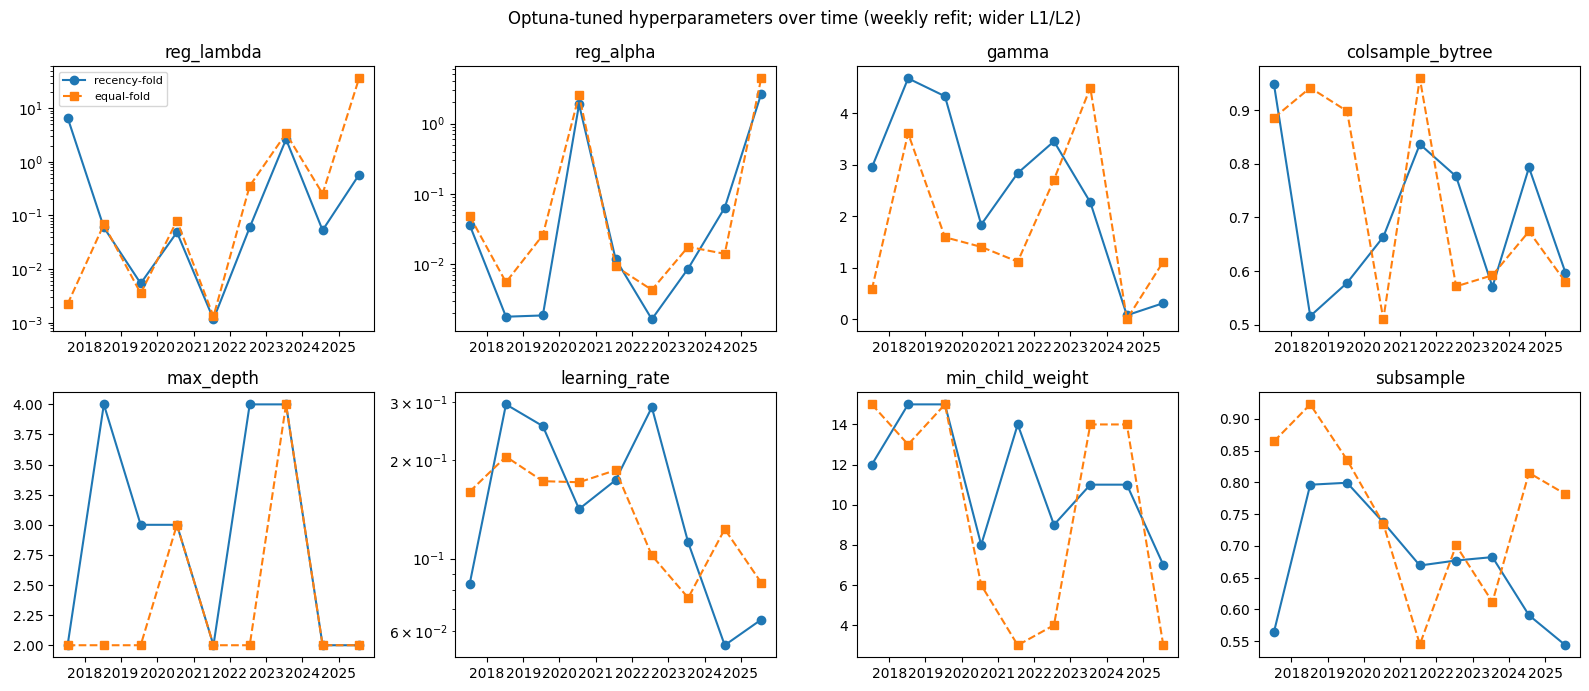

In [10]:
# ===========================================================================
# Cell 8 — Regularisation / hyperparameter trajectory across the annual studies
# ===========================================================================
plot_cols = ["reg_lambda", "reg_alpha", "gamma", "colsample_bytree",
             "max_depth", "learning_rate", "min_child_weight", "subsample"]
fig, axes = plt.subplots(2, 4, figsize=(16, 7))
for ax, c in zip(axes.ravel(), plot_cols):
    ax.plot(params_rec.index, params_rec[c], "o-", label="recency-fold")
    ax.plot(params_eq.index, params_eq[c], "s--", label="equal-fold")
    ax.set_title(c)
    if c in ("learning_rate", "reg_lambda", "reg_alpha"):
        ax.set_yscale("log")
axes[0, 0].legend(fontsize=8)
fig.suptitle("Optuna-tuned hyperparameters over time (weekly refit; wider L1/L2)")
fig.tight_layout(); fig.savefig("xgb_optuna_weekly_params.png", dpi=150); plt.show()

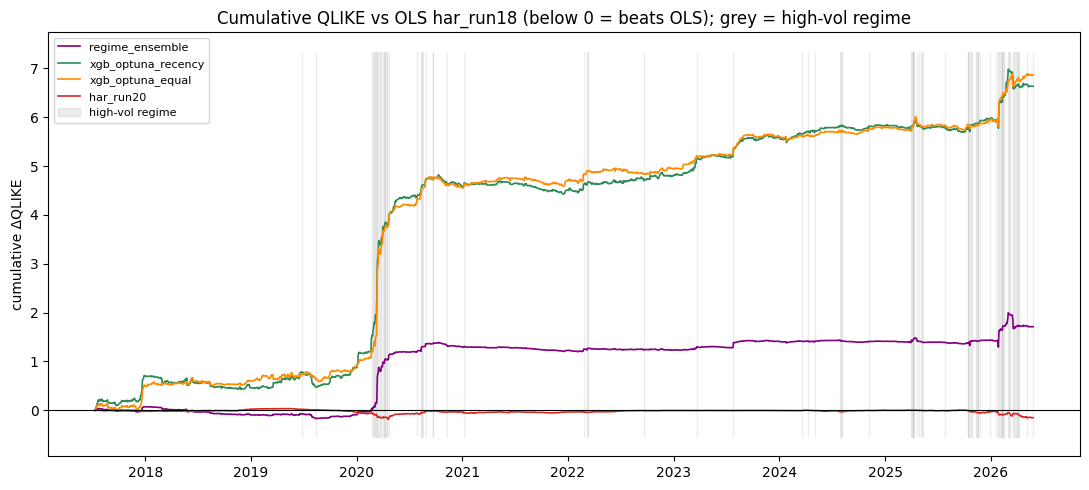

In [11]:
# ===========================================================================
# Cell 9 — Cumulative QLIKE vs OLS (har_run18): does the regime ensemble help?
# ===========================================================================
fig, ax = plt.subplots(figsize=(11, 5))
for name, color in [("regime_ensemble", "purple"), ("xgb_optuna_recency", "seagreen"),
                    ("xgb_optuna_equal", "darkorange"), ("har_run20", "C3")]:
    ax.plot(losses.index, (losses[name] - losses["har_run18"]).cumsum(), label=name, color=color, lw=1.2)
ax.axhline(0, color="k", lw=0.8)
# shade high-vol regime days
ax.fill_between(losses.index, ax.get_ylim()[0], ax.get_ylim()[1],
                where=regime_high, color="grey", alpha=0.15, label="high-vol regime")
ax.set_title("Cumulative QLIKE vs OLS har_run18 (below 0 = beats OLS); grey = high-vol regime")
ax.set_ylabel("cumulative ΔQLIKE"); ax.legend(fontsize=8)
fig.tight_layout(); fig.savefig("xgb_optuna_regime_cumqlike.png", dpi=150); plt.show()

## Why it matters: what the shallow trees tell us

Across the annual studies Optuna consistently selects **very shallow trees** (`max_depth` 2, occasionally 3),
even though depth 4 is allowed. Statistically, **tree depth is the order of interactions the model can
represent**: a depth-`d` tree can only combine up to `d` features along any root-to-leaf path. So a boosted
ensemble of depth-2 trees is restricted to **main effects plus at most pairwise (2-way) interactions**
(`f(x) = Σⱼ gⱼ(xⱼ) + Σⱼₖ gⱼₖ(xⱼ,xₖ)`) — i.e. only the low-order terms of the functional-ANOVA expansion.
Each shallow tree is a **high-bias, low-variance weak learner** (depth 2 → ≤ 4 leaves), and the ensemble's
flexibility comes from the *number* of boosting rounds, not the depth; choosing shallow trees is therefore an
implicit **regularisation on interaction complexity**.

The optimiser landing on depth 2 means the data is telling us that **the conditional mean of next-day RV is, to
a good approximation, an additive / near-linear function of the lags + GVZ + macro — there are essentially no
useful high-order nonlinear interactions to exploit.** That is exactly the regime in which the **linear HAR is
well-specified**: the HAR *is* an additive linear model in those terms. When the truth is additive and
near-linear, a flexible learner that tunes itself back down to "additive + a little pairwise" can at best match
the linear model and typically pays a small efficiency/variance cost — which is precisely the ≈11% QLIKE gap to
`har_run18` seen above.

**Takeaway:** Optuna's consistent selection of depth-2 trees indicates the predictable structure in gold RV is
essentially additive with at most weak pairwise interactions; the nonlinear capacity of gradient boosting is
left unused, which is why it cannot improve on the linear HAR. The same message appears in the regularisation
choices (small L1/L2, modest `colsample_bytree ≈ 0.66`) and in the stability of the feature ranking — the
signal is simply **low-complexity**, so added model flexibility does not pay. The regime-aware ensemble is the
direct test of whether XGBoost's only plausible edge — sharp, nonlinear spikes in **high-vol** periods — is
real: see the per-regime breakdown above.